# Relating Brain to Stimuli


## 0. Prepare notebook (import, plot parameters)

Setting up the notebook, every import should be taken care of here. The second cell is mostly there for aesthetics purposes, so I encourage you to play around with it and find what you find the most visually pleasing! Careful with the dpi however as it will affect the size of all subsequent figures.

In [ ]:
%load_ext autoreload
%autoreload 2

# Other useful imports
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import mne
import scipy.signal as signal
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA, FastICA
import time
from scipy.signal import welch
from IPython.display import clear_output

# Spyeeg import
from spyeeg.generate import simulate_channels, simulate_multisensory_channels, simulate_continuous_stimuli, simulate_PAC
import spyeeg.models as models

: 

In [ ]:
mpl.rcParams.update(mpl.rcParamsDefault)

%matplotlib inline
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=["b", "r", "g"])
mpl.rcParams['axes.grid'] = True
mpl.rcParams['axes.linewidth'] = 0.4
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['font.size'] = 3.5
mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['grid.alpha'] = 0.4
mpl.rcParams['grid.linewidth'] = 0.2
mpl.rcParams['lines.linewidth'] = 0.6


## 1. The idea behind Encoding
Vizualizing an LTI system: simple but useful model of brain response.

### 1.a Analogy with ERP
Here we simulate an electrophysiological signal which responds as a linear time-invariant system in response to discrete stimuli, it means that its response:
1) is consistent in time, similarly to the usual assumption behind ERP.
2) is a waveform which amplitude linearly depends on the amplitude of the stimuli.

To do so, we are using the simulate_channels function. It mostly serves to simulate random data so feel free to play around with the parameters.

Weights have incoherent shape relative to number of features, set to equal weights


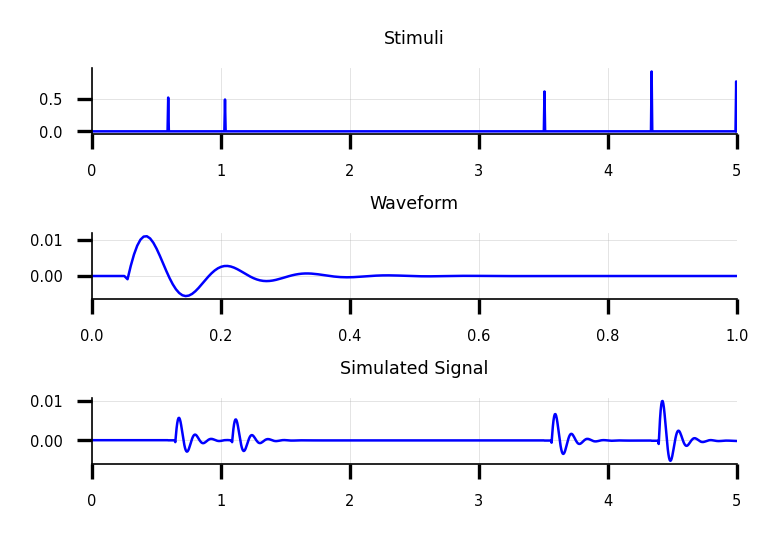

In [ ]:
# Generate the Data without noise
fs = 200
n_feat = 1
n_channels = 1
T = 5
time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,
                                                              stim_type = 'discrete', n_pulse = T,
                                                              impulse_freqs = [1,10], decreasing_rates = [10,25], delays = [0.03,0.1],
                                                              weights_feat = [], weights_channel = [1,5],
                                                              compression_factor = 1, share_impulse = True,
                                                              snr_db = np.inf, beta_noise = 0.4, #0 = white, 1 = pink, 2 = red
                                                              random_seed = 5, scale_data = False)


# Plot the Simulated Data

fig, ax = plt.subplots(3,figsize = (2.5,1.7))
ax[0].plot(time_array,X)
for i in range(n_feat):
    for j in range(n_channels):
        ax[1].plot(time_array,impulse_responses[i,j])
ax[2].plot(time_array,Y)

for i in range(3):
    ax[i].set_title(['Stimuli', 'Waveform', 'Simulated Signal'][i])
ax[0].set_xlim([0,5])
ax[1].set_xlim([0,1])
ax[2].set_xlim([0,5])
fig.tight_layout()

### 1.b Application to a continuous stimuli
While the response of an LTI is very straightforward and well-defined for discrete stimuli, it can actually be extended to continuous ones quite easily. An easy way to represent that idea is to imagine that at each point of time, the brain responds a discrete stimuli, which amplitude is the one of the continuous stimuli at that point in time.
We only need to change the "stim_type" parameter in the function to observe such a response.

Weights have incoherent shape relative to number of features, set to equal weights


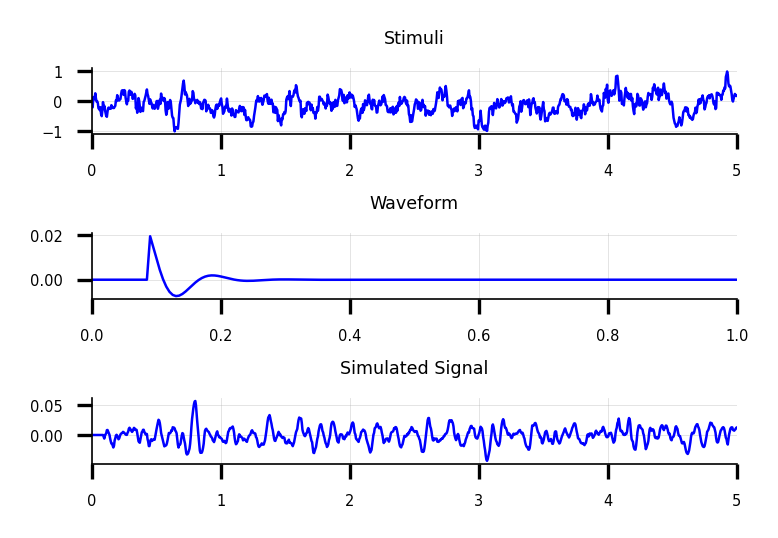

In [ ]:
# Generate the Data without noise
fs = 200
n_feat = 1
n_channels = 1
T = 5
time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,
                                                              stim_type = 'continuous', n_pulse = T,
                                                              impulse_freqs = [1,10], decreasing_rates = [10,25], delays = [0.03,0.1],
                                                              weights_feat = [], weights_channel = [1,5],
                                                              compression_factor = 1, share_impulse = True,
                                                              snr_db = np.inf, beta_noise = 0.4, #0 = white, 1 = pink, 2 = red
                                                              random_seed = 5, scale_data = False)

# Plot simulated data
fig, ax = plt.subplots(3,figsize = (2.5,1.7))
ax[0].plot(time_array,X)
for i in range(n_feat):
    for j in range(n_channels):
        ax[1].plot(time_array,impulse_responses[i,j])
ax[2].plot(time_array,Y)

for i in range(3):
    ax[i].set_title(['Stimuli', 'Waveform', 'Simulated Signal'][i])
ax[0].set_xlim([0,5])
ax[1].set_xlim([0,1])
ax[2].set_xlim([0,5])
fig.tight_layout()

### 1.c "Realistic" Data
Depending on the recording modality (intracortical shaft electrodes, ECoG, EEG, MEG...etc) and experimental design, the multidimensional signal will present different specificity: inter-channel correlation, spatio-temporal resolution, signal-to-noise ratio, duration. Here, for efficiency purposes, we will take the example of low-dimensional, high-snr, highly-correlated signal in response to a single stimuli for 10 minutes at 100Hz. This is typically the case of ECoG.
To achieve this, we will simply change the sampling frequency, n_feat, n_channels, share_impulse, weights_channel and snr_db parameters of our function.
Please be aware that while we define a pinkish noise here, it would probably corresponds to "background" brain activity in a realistic case, what we define as noise or not

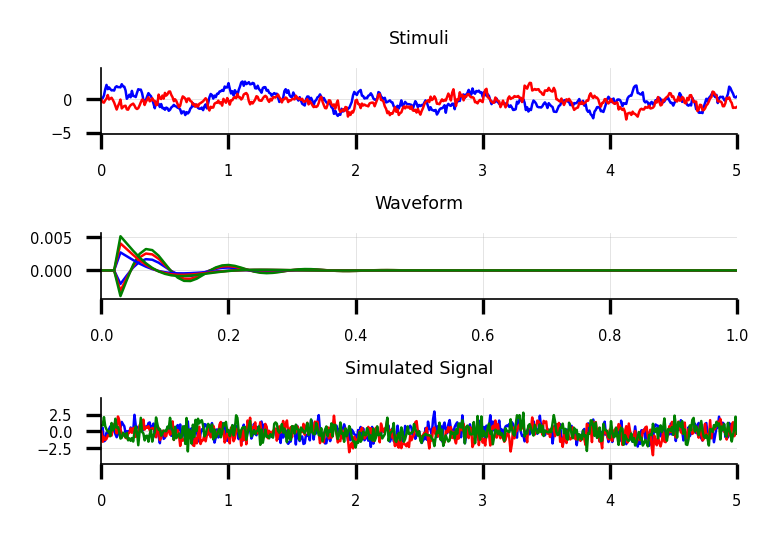

In [ ]:
# Generate the Data with noise over 3 channels
fs = 100
n_feat = 2
n_channels = 3
T = 600
time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,
                                                              stim_type = 'continuous', n_pulse = T,
                                                              impulse_freqs = [1,10], decreasing_rates = [10,25], delays = [0.03,0.1],
                                                              weights_feat = [], weights_channel = [1,1.5,1.9],
                                                              compression_factor = 1, share_impulse = True,
                                                              snr_db = -10, beta_noise = 0.4, #0 = white, 1 = pink, 2 = red
                                                              random_seed = 0, scale_data = True)


# Plot simulated data
fig, ax = plt.subplots(3,figsize = (2.5,1.7))
ax[0].plot(time_array,X)
for i in range(n_feat):
    for j in range(n_channels):
        ax[1].plot(time_array,impulse_responses[i,j])
ax[2].plot(time_array,Y)

for i in range(3):
    ax[i].set_title(['Stimuli', 'Waveform', 'Simulated Signal'][i])
ax[0].set_xlim([0,5])
ax[1].set_xlim([0,1])
ax[2].set_xlim([0,5])
fig.tight_layout()

## 2. Technical Considerations
From stimulus to brain: how is information encoded in the brain. Here, our goal is to use the LTI as a framework to represent the response of individual channels to a (or multiple) stimuli. First we'll define data to simulate 10 minutes of neural recordings.

In [ ]:
# Generate Data for 3 channels in response to a single feature for 10 minutes.
fs = 100
n_feat = 1
n_channels = 3
T = 600
time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,
                                                              stim_type = 'continuous', n_pulse = T,
                                                              impulse_freqs = [1,10], decreasing_rates = [10,25], delays = [0.03,0.1],
                                                              weights_feat = [], weights_channel = [1,1.5,1.9],
                                                              compression_factor = 1, share_impulse = True,
                                                              snr_db = -15, beta_noise = 0.4, #0 = white, 1 = pink, 2 = red
                                                              random_seed = 0, scale_data = False)

### 2.a Understanding the Temporal Response Function
Once the concept of LTI is understood, the TRF is actually quite obvious as it simply consists of directly learning the weights representing the response waveform (the "response function" if you will). Here we simply present how the TRF function operate in a typical case and the (very few) different steps to achieve results. We won't define these steps later so make sure to understand what we do, these lines will be repeated quite often!

In [ ]:
# First we define parameters relative to the TRF fitting: the temporal window (tmin, tmax), the regularization sweep (alphas)
# the fitting domain (fit_domain), the metrics to measure performance (metrics) and number of folds for the cross-validation (n_folds)
tmin = 0
tmax = 0.5
alphas = np.logspace(-3,3,10)
fit_domain = 'time'
metrics = 'R2'
n_folds = 5

# Then we declare the TRF: this allows to manipulate it as an object that stores all relevant information rather than just a function.
trf = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas, fit_domain = fit_domain)

# Before fitting anything, it is ESSENTIAL to do proper preprocessing. As the saying goes in Machine Learning: "trash in, trash out", so have data as clean as possible
# In our case, this only involves properly scaling the data, the TRF does not fit the intercept and therefore everything needs to be centered in 0.
X = scale(X)
Y = scale(Y)

# Now, we can fit the data using cross-fold validation
trf.xval_eval(X, Y, n_splits = n_folds, scoring = metrics,verbose = False)

# The trf object is now fitted and we can extract the scores, the TRF coefficients...etc
trf_times = trf.times
scores = trf.scores
coefficients = trf.get_coef()

We've now obtained scores (according to the chosen metrics, here R2) and coefficients, let's take a look at their shape!

In [ ]:
print("Scores have a shape of (n_folds,n_channels,n_alphas): ", scores.shape)
print("Coefficients have a shape of (window_width, n_features, n_channels, n_alphas): ", coefficients.shape)

Scores have a shape of (n_folds,n_channels,n_alphas):  (5, 3, 10)
Coefficients have a shape of (window_width, n_features, n_channels, n_alphas):  (50, 1, 3, 10)


The folds are always averaged and generally the best alpha is chosen. When multiple subjects are presented, it is good practise to choose the average alpha parameter, or better even, do nested cross-validation. This however can be time consuming, so it depends on your needs and data. Here, we'll select the best alpha. We will plot the coefficient and thus compare our ideal impulse response to the one computed via the TRF.

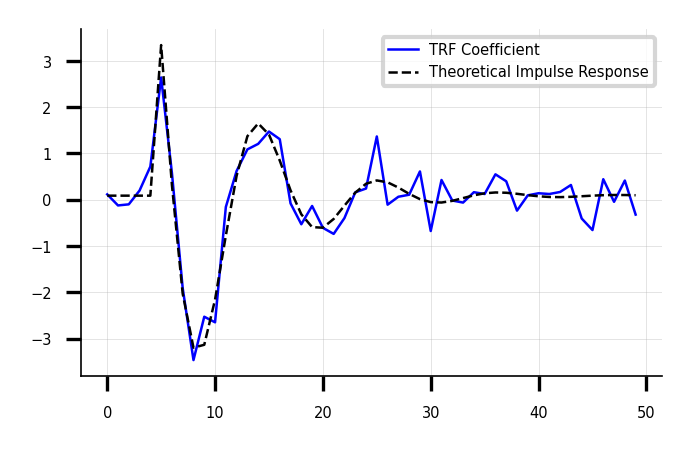

In [ ]:
fig, ax = plt.subplots(figsize = (2.5,1.5))
ax.plot(scale(coefficients[:50,0,0,2]), label = 'TRF Coefficient')
ax.plot(scale(impulse_responses[0,0,0:50]), ls = '--',color = 'k', label = 'Theoretical Impulse Response', alpha = 1)
ax.legend(fancybox = True)

### 2.b Testing the metrics
Once the signal is reconstructed, different metrics can be used to quantify the quality of the fit. They are generally related and have different uses depending on the scenario. We will also briefly talk of their signification and how the nomenclature can be misleading (R squared is not the square of R...at least, not always!). But first, let's plot our reconstructed signal vs the actual signal

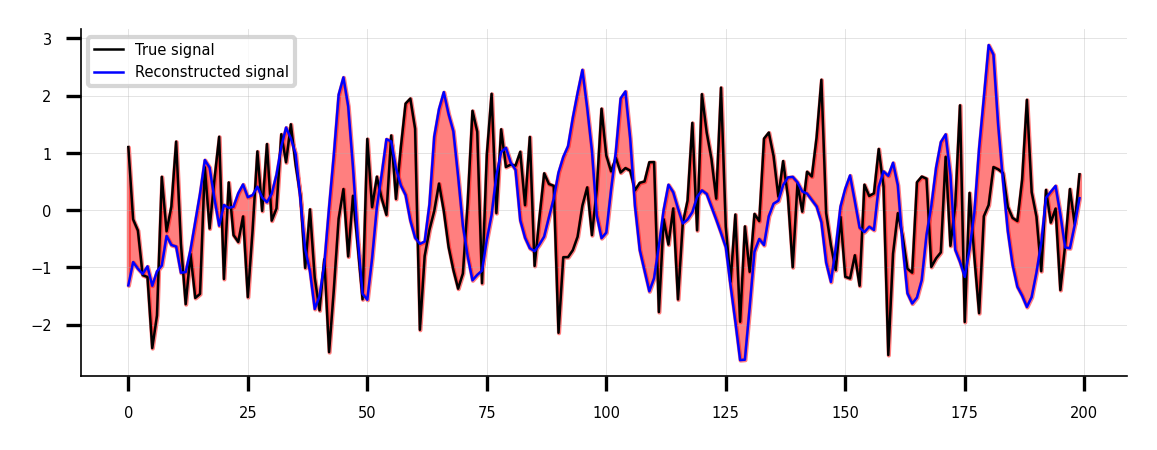

In [ ]:
fig, ax = plt.subplots(figsize = (4.5,1.5))
ax.plot(scale(Y[300:500,0]), color = 'k', label = 'True signal')
ax.plot(scale(trf.predict(X)[300:500,0,2]), label = 'Reconstructed signal')
ax.fill_between(np.arange(200),scale(trf.predict(X)[300:500,0,2]), scale(Y[300:500,0]), alpha = 0.5, color = 'r')
ax.legend()


#### Different metrics to quantify different aspects
There exist different metrics to quantify the difference between two time series, however here, we will take a "linear regression approach" and focus on 3 metrics: explained variance (R2), Pearson correlation (corr) and Spearman correlation (rankcorr).

In [ ]:
tmin = 0
tmax = 1
metrics = ['R2', 'corr', 'rankcorr']
scores = np.zeros([len(metrics), n_channels])
for i_metric, metric in enumerate(metrics):
    trf = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = [0,1])
    trf_times = trf.times
    trf.xval_eval(X, Y, scoring = metric, verbose = False)
    scores[i_metric] = trf.scores.mean(0).max(-1)

Overall, the 3 metrics gives similar results and conserve order between channel most of the time. The main difference being that R2 can go down to infinity, while correlations are between -1 and 1. This will be important in the future as it means different metrics have different noise floor and establishing "absolute" threshold is a harduous(and probabily meaningless) task.

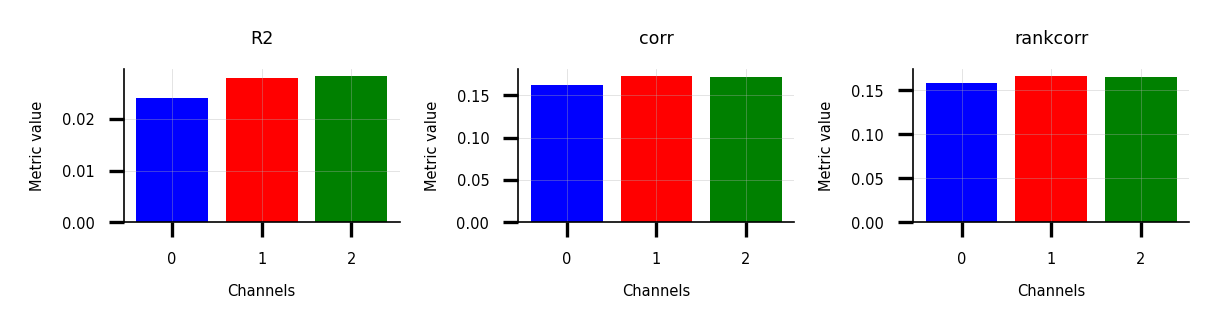

In [ ]:
fig, ax = plt.subplots(1,len(metrics), figsize = (4,1))
for i_metric in range(len(metrics)):
    ax[i_metric].bar(np.arange(3),scores[i_metric], color = ['b','r','g'])
    ax[i_metric].set_title(metrics[i_metric])
    ax[i_metric].set_xticks(np.arange(n_channels))
    ax[i_metric].set_xlabel('Channels')
    ax[i_metric].set_ylabel('Metric value')
fig.tight_layout()

#### R2 is negatively biased
One important aspect of the R2 measure, which is the most commonly used, is that it is negatively biased. This means that adding noisy data to the model will bias it negatively, despite no positive or negative information being added. This is simply due to a form of overfitting, the algorithm can detect small pattern in the training set, which result in negative explained variance as this does not generalize to the testing set. Here we will play with the length of the window, essentially adding useless parameters to the model to test differently sized TRF.

In [ ]:
tmin = 0
tmax_list = [0.5,1,2]
metric = 'R2'
scores = np.zeros([len(tmax_list), n_channels])
for i_tmax, tmax in enumerate(tmax_list):
    trf = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = [0,1])
    trf_times = trf.times
    trf.xval_eval(X, Y, scoring = metric, verbose = False)
    scores[i_tmax] = trf.scores.mean(0).max(-1)

Overall all, we observe a clear negative bias proportionally to the window length. This is also applicable to the number of features, as these increase the size of the model

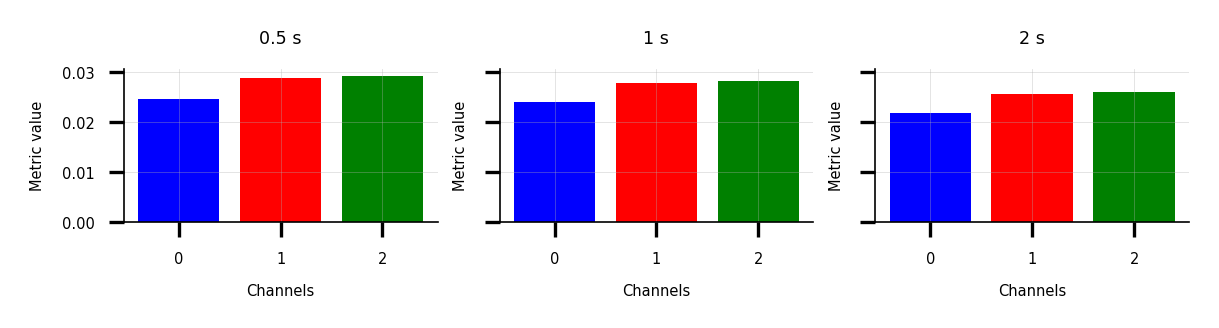

In [ ]:
fig, ax = plt.subplots(1,len(metrics), figsize = (4,1), sharey = True)
for i_tmax in range(len(tmax_list)):
    ax[i_tmax].bar(np.arange(3),scores[i_tmax], color = ['b','r','g'])
    ax[i_tmax].set_title(str(tmax_list[i_tmax]) + ' s')
    ax[i_tmax].set_xticks(np.arange(n_channels))
    ax[i_tmax].set_xlabel('Channels')
    ax[i_tmax].set_ylabel('Metric value')
fig.tight_layout()

#### Comparison of differently sized models
Because of this bias, it is essential to compare models of same size. Here, we demonstrate it by create several models with the same "useful" feature and a certain number of noisy features and compare their performance.

In [ ]:
tmin = 0
tmax = 0.5
metric = 'R2'
n_noisy_features = 3
scores = np.zeros([n_noisy_features, n_channels])
for i_noise in range(n_noisy_features):
    X1 = np.random.random((X.shape[0], i_noise))
    X_tot = scale(np.hstack([X,X1]))
    trf = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = [0,1])
    trf_times = trf.times
    trf.xval_eval(X_tot, Y, scoring = metric, verbose = False)
    scores[i_noise] = trf.scores.mean(0).max(-1)

Predictably, the R2 decreases with the size of the model: Be careful with what you put in your model, there's no point in putting useless features.

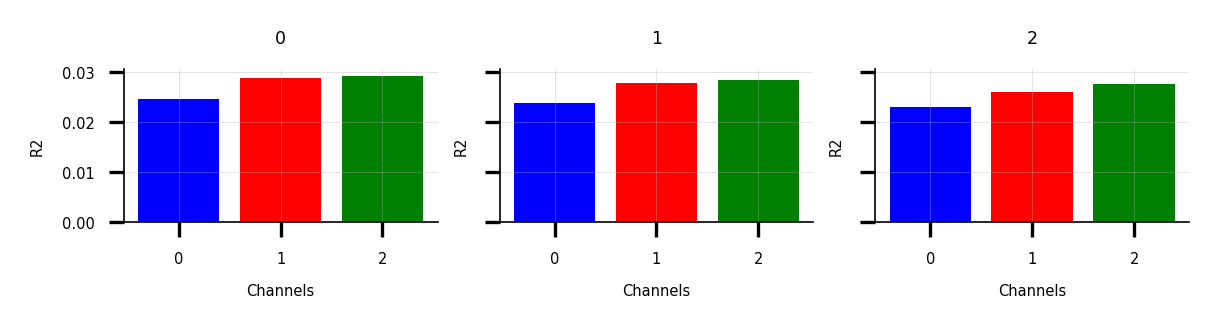

In [ ]:
fig, ax = plt.subplots(1,n_noisy_features, figsize = (4,1), sharey = True)
for i_noise in range(n_noisy_features):
    ax[i_noise].bar(np.arange(3),scores[i_noise], color = ['b','r','g'])
    ax[i_noise].set_title(str(i_noise))
    ax[i_noise].set_xticks(np.arange(n_channels))
    ax[i_noise].set_xlabel('Channels')
    ax[i_noise].set_ylabel('R2')
fig.tight_layout()

### 2.c Cross-Validation

Cross-validation is a standard procedure in machine learning, which aims at avoiding data leaking while having access to a large training set. Here we will demonstrate its usefulness by showing the difference between results with and without cross-validation (i.e. with or without data leak). First let's compare results for a model with "actual data" i.e. the simulated signal contains information about the feature.

In [ ]:
tmin = 0
tmax = 0.5
scores = np.zeros([2, n_channels])

trf_xval = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = [0,1])
trf_times = trf_xval.times
trf_xval.xval_eval(X, Y, scoring = metric, verbose = False)
scores[0] = trf_xval.scores.mean(0).max(-1)

trf_leak = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = [0,1])
coefs = trf_leak.fit(X,Y)
scores[1] = trf_leak.score(X,Y).max(1)

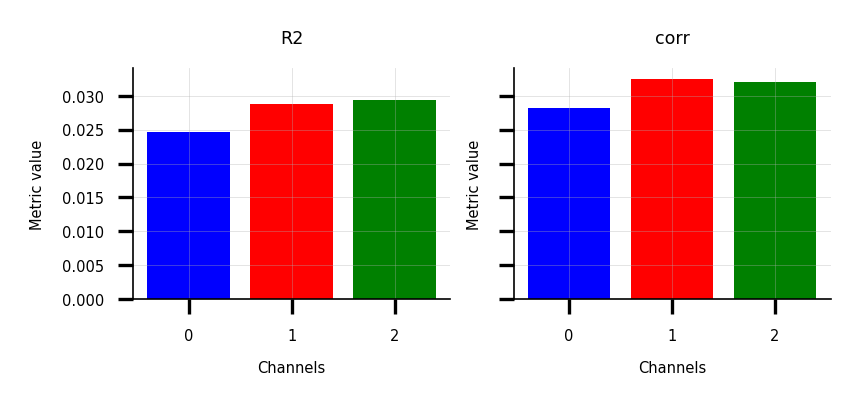

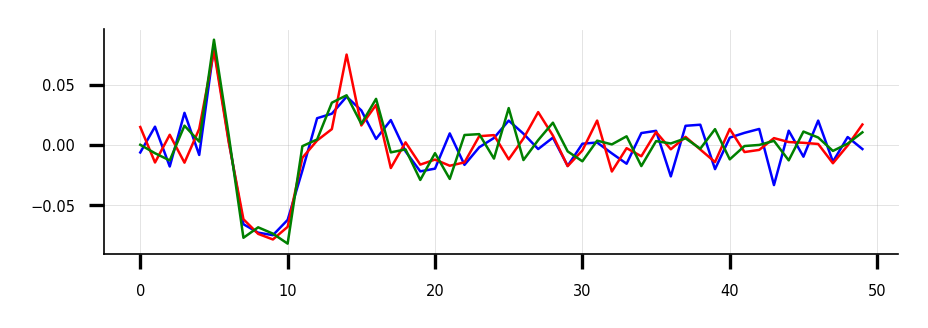

In [ ]:
fig, ax = plt.subplots(1,2, figsize = (3,1), sharey = True)
for i in range(2):
    ax[i].bar(np.arange(3),scores[i], color = ['b','r','g'])
    ax[i].set_title(metrics[i])
    ax[i].set_xticks(np.arange(n_channels))
    ax[i].set_xlabel('Channels')
    ax[i].set_ylabel('Metric value')
fig, ax = plt.subplots(figsize = (3,1))
ax.plot(coefs[::-1,:,0])
fig.tight_layout()

Overall, we just observe that the non-cross validated scores are higher, we could think that, fine, they're just positively biased, but let's look at what happens if we put noise as a feature instead of anything relevant.

In [ ]:
tmin = 0
tmax = 0.5
scores = np.zeros([2, n_channels])
X_noise = np.random.random(X.shape)

trf_xval = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = [0,1])
trf_times = trf_xval.times
trf_xval.xval_eval(X_noise, Y, scoring = metric, verbose = False)
scores[0] = trf_xval.scores.mean(0).max(-1)

trf_leak = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = [0,1])
coefs = trf_leak.fit(X_noise,Y)
scores[1] = trf_leak.score(X_noise,Y).max(1)

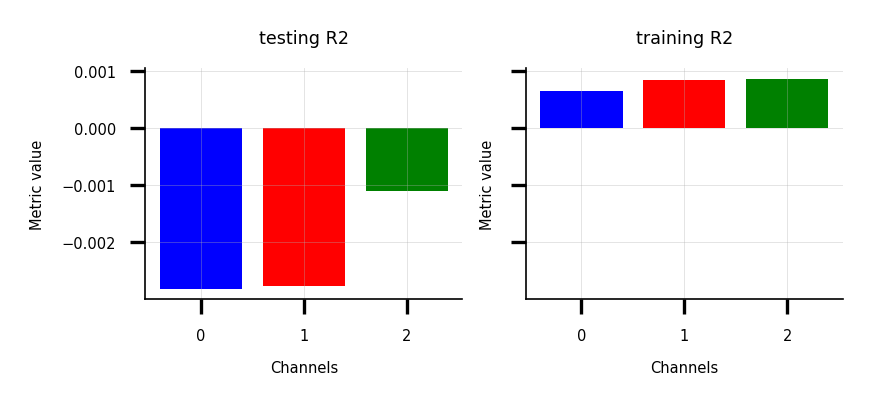

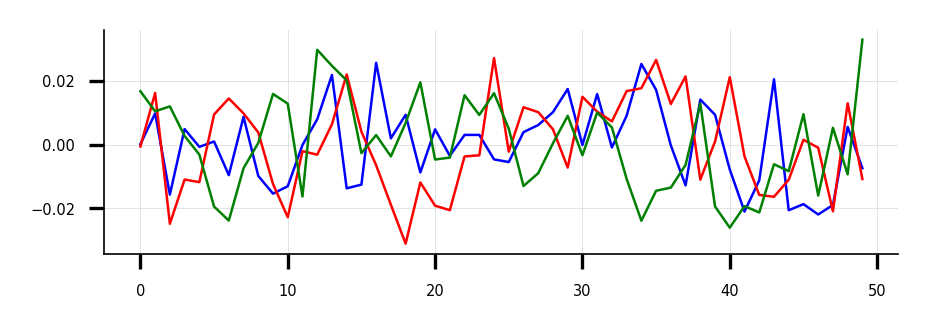

In [ ]:
fig, ax = plt.subplots(1,2, figsize = (3,1), sharey = True)
for i in range(2):
    ax[i].bar(np.arange(3),scores[i], color = ['b','r','g'])
    ax[i].set_title(['testing R2', 'training R2'][i])
    ax[i].set_xticks(np.arange(n_channels))
    ax[i].set_xlabel('Channels')
    ax[i].set_ylabel('Metric value')
fig, ax = plt.subplots(figsize = (3,1))
ax.plot(coefs[::-1,:,0])
fig.tight_layout()

There is obviously no pattern in the coefficients, but the R2 are still positive: this is due to overfitting. If these coefficients were used on a separate set of data, there would be no generalization, hence why cross-validated scores are negative (0 - bias).

### 2.d Regularization
Regularization is commonly used in ill-posed regression problem to avoid "putting all of the weights on one feature". And as a regression problem, the TRF is fundamentally ill-posed for continuous regressors, as they are strongly auto-correlated i.e. we do a multilinear regression with strongly correlated features. Therefore, if a single lag gets 'all the weights', the trained coefficients are non-generalizable. To solve this problem, we add a regularization parameter, essentially constraining our model and forcing it to learn regularized weights. Regularization can take different forms but the spyeeg module is optimized for speed using a specific sort.

In [ ]:
# Generate Data for 3 channels in response to a single feature for 10 minutes.
fs = 100
n_feat = 1
n_channels = 1
T = 600
time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,
                                                              stim_type = 'continuous', n_pulse = T,
                                                              impulse_freqs = [1,10], decreasing_rates = [10,25], delays = [0.03,0.1],
                                                              weights_feat = [], weights_channel = [1],
                                                              compression_factor = 1, share_impulse = True,
                                                              snr_db = -20, beta_noise = 0.4, #0 = white, 1 = pink, 2 = red
                                                              random_seed = 0, scale_data = False)

In [ ]:
tmin = 0
tmax = 1
alphas = [0] + list(np.logspace(-5,5,20))

trf = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas)
trf_times = trf.times
trf.xval_eval(X, Y, scoring = metric, verbose = False)
scores = trf.scores.mean(0)[0]
coefficients = trf.get_coef()[:,0,0,:]


Let's take a look at how our scores and coefficients change with different regularization parameters, we should observe a smoothing effect.

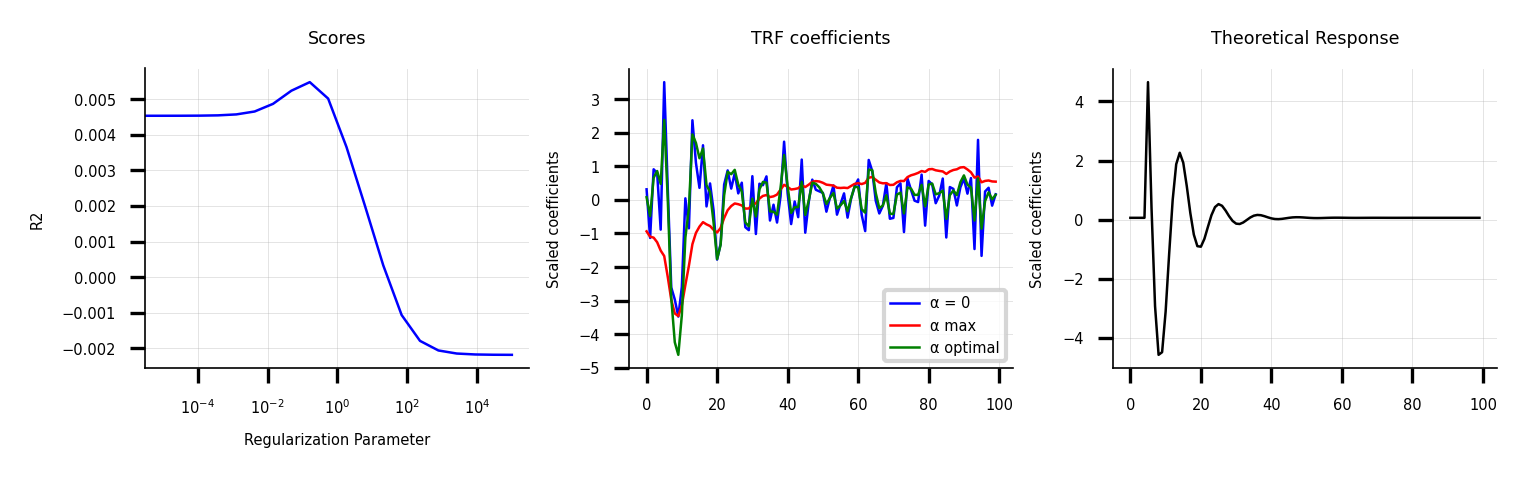

In [ ]:
fig,ax = plt.subplots(1,3,figsize = (5,1.5))
ax[0].plot(alphas, scores)
ax[0].set_ylabel('R2')
ax[0].set_xlabel('Regularization Parameter')
ax[0].set_xscale('log')
ax[0].set_title('Scores')

for i in range(3):
    ax[1].plot(scale(coefficients[:,[0,-1,np.argmax(scores)][i]]), label = ['α = 0', 'α max', 'α optimal'][i])
ax[1].legend()
ax[1].set_title('TRF coefficients')
ax[1].set_ylabel('Scaled coefficients')

ax[2].plot(scale(impulse_responses[0,0,:100]), color = 'k')
ax[2].set_title('Theoretical Response')
ax[2].set_ylabel('Scaled coefficients')

fig.tight_layout()

### 2.e Model Comparison and Statistical Evaluation
Often, fitting a single model does not tell us a lot about what's going on. Here we will talk about how to compare models, what models to compare, with an emphasis on the concept of null distribution and the importance of same-size models. We will see that even a negative R2 can be linked to actual activity, provided we use proper statistical analysis.

In [ ]:
# Generate Data for 3 channels in response to a single feature for 10 minutes.
fs = 100
n_feat = 1
n_channels = 1
T = 600
time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,
                                                              stim_type = 'continuous', n_pulse = T,
                                                              impulse_freqs = [1,10], decreasing_rates = [10,25], delays = [0.03,0.1],
                                                              weights_feat = [], weights_channel = [1,1.5,1.9],
                                                              compression_factor = 1, share_impulse = True,
                                                              snr_db = -30, beta_noise = 0.4, #0 = white, 1 = pink, 2 = red
                                                              random_seed = 0, scale_data = False)

Weights have incoherent shape relative to number of features, set to equal weights


In [ ]:
tmin = 0
tmax = 0.5
alphas = [0] + list(np.logspace(-2,2,10))
n_perm = 100
X_perm = np.zeros([X.shape[0],1])
scores_perm = np.zeros([n_channels,n_perm])
start = time.time()
for i in range(n_perm):
    X_perm[:,0] = np.roll(X[:,0],np.random.randint(100,X.shape[0] - 100))
    trf_perm = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas)
    scores_perm[:,i] = trf_perm.xval_eval(X_perm, Y, scoring = 'R2', verbose = False).mean(0).max(-1)

trf = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas)
scores = trf_perm.xval_eval(X, Y, scoring = 'R2', verbose = False).mean(0).max(-1)
print(time.time() - start)

43.34677982330322


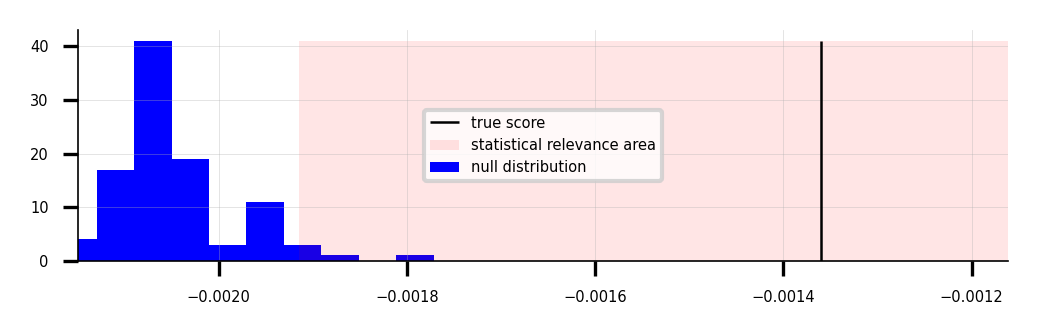

In [ ]:
fig, ax = plt.subplots(figsize = (4,1))
nb, bins = np.histogram(scores_perm[0])
ax.bar(x = bins[:-1], height = nb, width = bins[1] - bins[0], label = 'null distribution')
ax.vlines(scores, 0, np.max(nb), ls = '-', color = 'k', label = 'true score')
ax.fill_between([np.percentile(scores_perm[0],95), 1], 0, np.max(nb), alpha = 0.1, label = 'statistical relevance area')
ax.set_xlim(np.min(bins), max(np.max(bins),scores) + (bins[1] - bins[0]) * 5)
ax.legend(loc = 'center')

### 2.f Computing Time: Understanding the technical constraints (bonus)

Almost every parameter has an impact on time:
- regularization parameter
- number of parameters
- duration of sample
- number of channels
The time dependence on the number of parameters is different for each of them and is inhenrently linked to the underlying computation we do. You can test for yourself and observe the results. Spoiler alert: spyeeg is optimized for speed and regularization has typically a lowered impact compared to similar libraries. Another spoiler, you can try using "fit_domain = frequency" and observe the magic at play (soon in press)

## 3. Applications of Encoding
After looking at different technical considerations on the use of linear encoding models, let's have a look at the methods used in various papers. The goal here is to develop an intuition for
1) What is the hypothesis I want to prove/disprove.
2) How to use the TRF to do so

### 3.a Multisensory Interaction
In the example we'll see here (https://www.pnas.org/doi/abs/10.1073/pnas.2117000119), the research question was: Is there a multisensory interaction between audio and tactile stimuli during speech processing. This comes down to the question of supra(or sub)-additive effect: Is the linear encoding model of multisensory data fundamentally different from a combination of models encoding unisensory data. Let's first generate such a set of data in the case where there is NO multisensory interaction.

(0.0, 10.0)

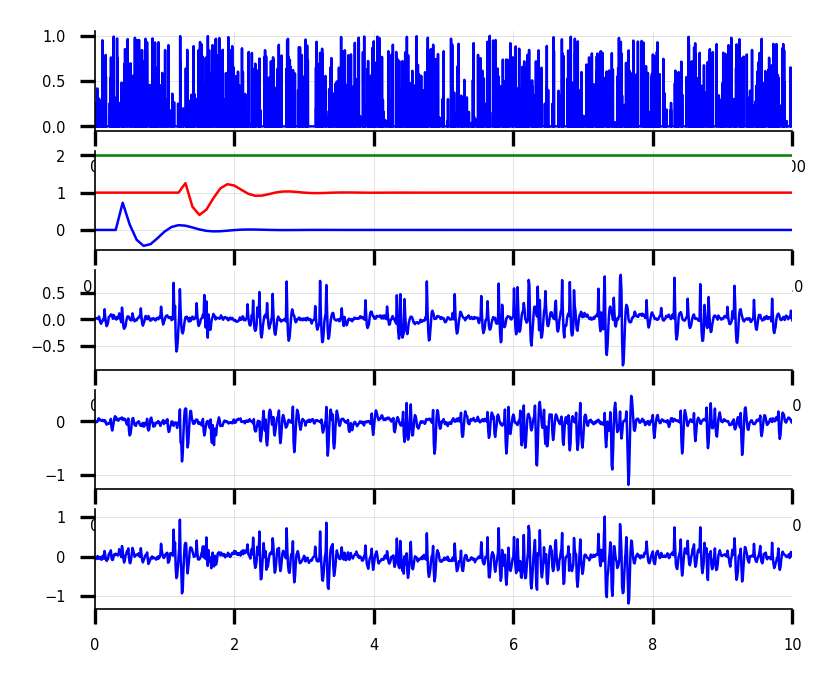

In [ ]:
fs = 100
n_feat = 1
n_channels = 1
T = 120
supra_amp = 0

time_array, X, Y1,Y2,Y12, events, impulse_responses = simulate_multisensory_channels(n_feat = n_feat, n_channels = n_channels,
                                                              fs = fs, T = T,
                                                              stim_type = 'discrete', n_pulse = T * 8,
                                                              impulse_freqs = [2,20], decreasing_rates = [20,25], delays = [0.03,0.2],
                                                              compression_factor = 1,
                                                              snr_db = 10, beta_noise = 1, #0 = white, 1 = pink, 2 = red
                                                              random_seed = 10, scale_data = False, supra_amp = supra_amp)
fig, ax = plt.subplots(5,figsize = (3,2.5), sharex = False)
ax[0].plot(time_array,X)
for i in range(n_feat):
    for j in range(n_channels):
        for k in range(2):
            ax[1].plot(time_array,impulse_responses[k,i,j] + k, alpha = 1)
        ax[1].plot(time_array,impulse_responses[2,i,j] - impulse_responses[0,i,j] - impulse_responses[1,i,j] + 2, alpha = 1)
ax[2].plot(time_array,Y1)
ax[3].plot(time_array,Y2)
ax[4].plot(time_array,Y12)
ax[0].set_xlim([0,100])
ax[1].set_xlim([0,1])
ax[2].set_xlim([0,10])
ax[3].set_xlim([0,10])
ax[4].set_xlim([0,10])


We can then compare the scores, as well as the coefficients to measure a possible supra-additive effect.

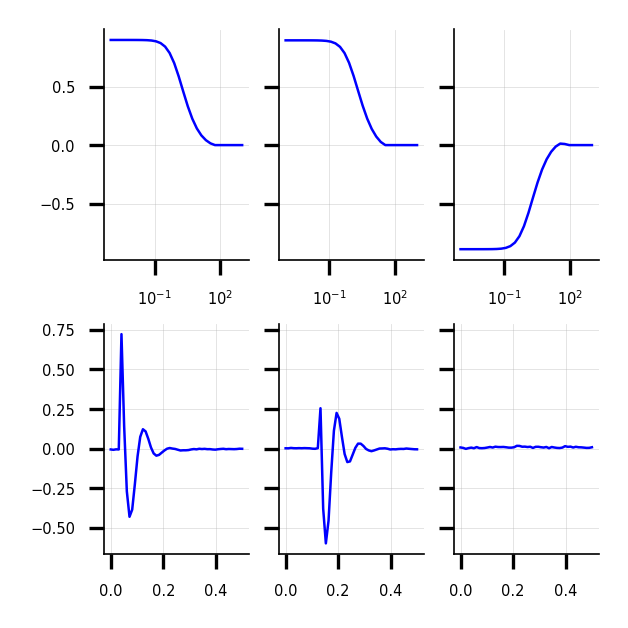

In [ ]:
tmin, tmax = 0,0.5
metrics = 'R2'
alphas = [0] + np.logspace(-3,3,30)
trf1 = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas)
scores1_trf = trf1.xval_eval(X, Y1, scoring = metrics, verbose = False)
scores1_trf = np.asarray([max(score,0) for score in scores1_trf.mean(0)[0]])

trf2 = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas)
scores2_trf = trf2.xval_eval(X, Y2, scoring = metrics, verbose = False)
scores2_trf = np.asarray([max(score,0) for score in scores2_trf.mean(0)[0]])

trf12 = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas)
scores12_trf = trf12.xval_eval(X, Y12, scoring = metrics, verbose = False)
scores12_trf = np.asarray([max(score,0) for score in scores12_trf.mean(0)[0]])

fig,ax = plt.subplots(2,3,figsize = (2,2), sharey = 'row')

kernel_time = np.linspace(tmin, tmax,int((tmax-tmin)*fs))
alpha_kernel = int(np.mean([trf1.get_best_alpha(),trf2.get_best_alpha(),trf12.get_best_alpha()]))


ax[0,0].plot(alphas,scores1_trf)
ax[0,1].plot(alphas,scores2_trf)
ax[0,2].plot(alphas, scores12_trf - scores1_trf - scores2_trf)
for i in range(3):
    ax[0,i].set_xscale('log')
ax[1,0].plot(kernel_time,scale(trf1.get_coef()[:,0,0,alpha_kernel] ** 1, with_mean = False, with_std = False))
ax[1,1].plot(kernel_time,scale(trf2.get_coef()[:,0,0,alpha_kernel] ** 1, with_mean = False, with_std = False))
ax[1,2].plot(kernel_time,scale((trf12.get_coef()[:,0,0,alpha_kernel] - trf1.get_coef()[:,0,0,alpha_kernel] - trf2.get_coef()[:,0,0,alpha_kernel]) ** 1, with_mean = False, with_std = False))

fig.tight_layout()

As expected, we observe no supra-additive effect (coefficients at 0), however, there is a small bump of R2, due to unoptimized alpha fitting. This means that we should careful with tuning hyperparameter as multisensory effects could happen as an artifact: tread carefully. Now, let's have a look at data actually containing a supra-additive interaction.

(0.0, 10.0)

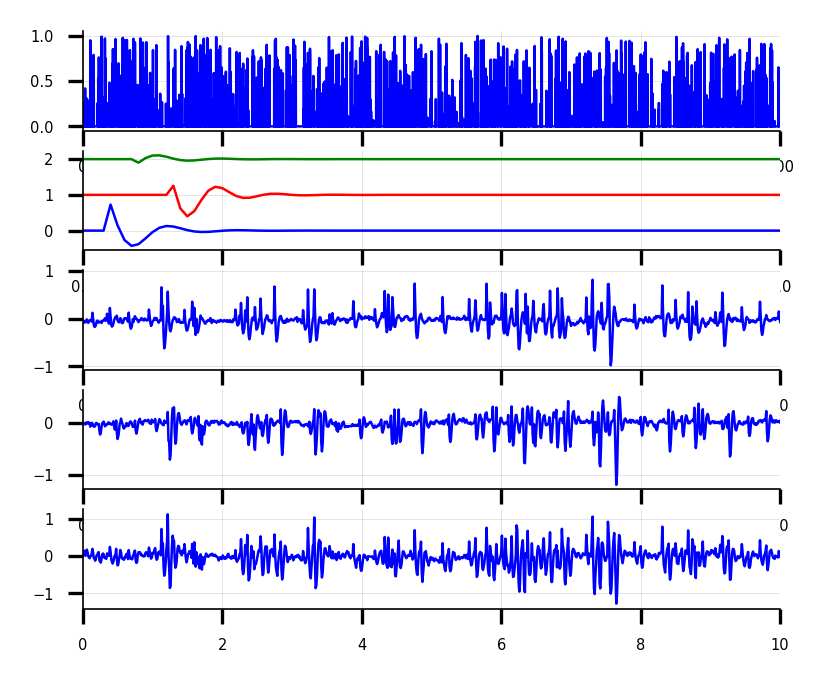

In [ ]:
fs = 100
n_feat = 1
n_channels = 1
T = 120
supra_amp = 0.2

time_array, X, Y1,Y2,Y12, events, impulse_responses = simulate_multisensory_channels(n_feat = n_feat, n_channels = n_channels,
                                                              fs = fs, T = T,
                                                              stim_type = 'discrete', n_pulse = T * 8,
                                                              impulse_freqs = [2,20], decreasing_rates = [20,25], delays = [0.03,0.2],
                                                              compression_factor = 1,
                                                              snr_db = 10, beta_noise = 1, #0 = white, 1 = pink, 2 = red
                                                              random_seed = 10, scale_data = False, supra_amp = supra_amp)
fig, ax = plt.subplots(5,figsize = (3,2.5), sharex = False)
ax[0].plot(time_array,X)
for i in range(n_feat):
    for j in range(n_channels):
        for k in range(2):
            ax[1].plot(time_array,impulse_responses[k,i,j] + k, alpha = 1)
        ax[1].plot(time_array,impulse_responses[2,i,j] - impulse_responses[0,i,j] - impulse_responses[1,i,j] + 2, alpha = 1)
ax[2].plot(time_array,Y1)
ax[3].plot(time_array,Y2)
ax[4].plot(time_array,Y12)
ax[0].set_xlim([0,100])
ax[1].set_xlim([0,1])
ax[2].set_xlim([0,10])
ax[3].set_xlim([0,10])
ax[4].set_xlim([0,10])


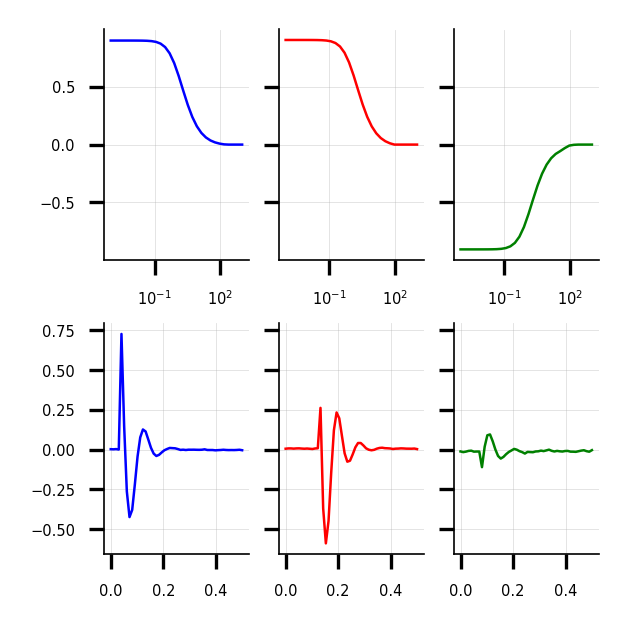

In [ ]:
tmin, tmax = 0,0.5
metrics = 'R2'
alphas = [0] + np.logspace(-3,3,30)
trf1 = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas)
scores1_trf = trf1.xval_eval(X, Y1, scoring = metrics, verbose = False)
scores1_trf = np.asarray([max(score,0) for score in scores1_trf.mean(0)[0]])

trf2 = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas)
scores2_trf = trf2.xval_eval(X, Y2, scoring = metrics, verbose = False)
scores2_trf = np.asarray([max(score,0) for score in scores2_trf.mean(0)[0]])

trf12 = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas)
scores12_trf = trf12.xval_eval(X, Y12, scoring = metrics, verbose = False)
scores12_trf = np.asarray([max(score,0) for score in scores12_trf.mean(0)[0]])

fig,ax = plt.subplots(2,3,figsize = (2,2), sharey = 'row')

kernel_time = np.linspace(tmin, tmax,int((tmax-tmin)*fs))
alpha_kernel = int(np.mean([trf1.get_best_alpha(),trf2.get_best_alpha(),trf12.get_best_alpha()]))


ax[0,0].plot(alphas,scores1_trf, color = 'b')
ax[0,1].plot(alphas,scores2_trf, color = 'r')
ax[0,2].plot(alphas, scores12_trf - scores1_trf - scores2_trf, color = 'g')
for i in range(3):
    ax[0,i].set_xscale('log')
ax[1,0].plot(kernel_time,scale(trf1.get_coef()[:,0,0,alpha_kernel] ** 1, with_mean = False, with_std = False), color = 'b')
ax[1,1].plot(kernel_time,scale(trf2.get_coef()[:,0,0,alpha_kernel] ** 1, with_mean = False, with_std = False), color = 'r')
ax[1,2].plot(kernel_time,scale((trf12.get_coef()[:,0,0,alpha_kernel] - trf1.get_coef()[:,0,0,alpha_kernel] - trf2.get_coef()[:,0,0,alpha_kernel]) ** 1, with_mean = False, with_std = False), color = 'g')

fig.tight_layout()

### 3.b Handling simple non-linearities
In this example, we'll see how we can explore simple non-linearities in the brain response, that could be linked with pre-existing knowledge about sensory systems (https://ieeexplore.ieee.org/abstract/document/7478117). The idea is to add a compression factor, that we suppose is the result of low-level processing (cochlear or thalamic for example), and see how we would test that.

In [ ]:
# Generate Data for 3 channels in response to a single feature for 10 minutes.
fs = 100
n_feat = 1
n_channels = 1
T = 600
compression_factor = 0.5
time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,
                                                              stim_type = 'continuous', n_pulse = T,
                                                              impulse_freqs = [1,10], decreasing_rates = [10,25], delays = [0.03,0.1],
                                                              weights_feat = [], weights_channel = [1],
                                                              compression_factor = compression_factor, share_impulse = True,
                                                              snr_db = -15, beta_noise = 0.4, #0 = white, 1 = pink, 2 = red
                                                              random_seed = 0, scale_data = False)

In [ ]:
non_linear_factors = np.arange(20)/10
alphas = [0] + list(np.logspace(-3,3,10))
scores = np.zeros(len(non_linear_factors))
for factor_index, factor in enumerate(non_linear_factors):
    X_nonlinear = scale(np.power(np.abs(X), factor) * np.sign(X))
    trf_nonlinear = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas)
    trf_nonlinear.xval_eval(X_nonlinear, Y, scoring = 'R2', verbose = False)
    scores[factor_index] = trf_nonlinear.scores.mean(0).max(-1)[0]

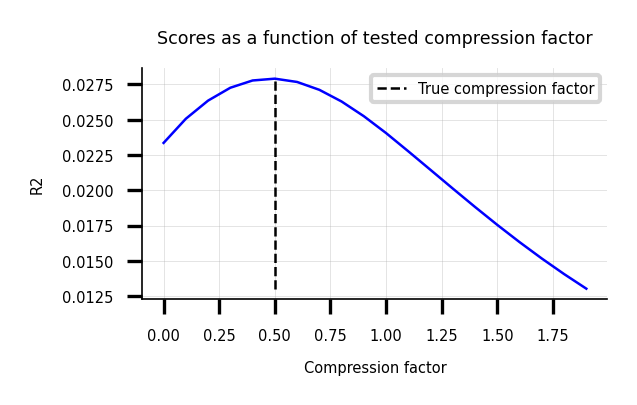

In [ ]:
fig, ax = plt.subplots(figsize = (2,1))
ax.plot(non_linear_factors, scores)
ax.vlines(compression_factor,np.min(scores),np.max(scores), color = 'k', ls = '--',label = 'True compression factor')
ax.set_title('Scores as a function of tested compression factor')
ax.set_ylabel('R2')
ax.set_xlabel('Compression factor')
ax.legend()

### 3.c Controlling for lower level features
Most of the time, we have a set of "control features", which we already know encode some brain activity. Wanting to test an additional hypothesis then becomes a question of "does this feature encode information in addition to these control features?". This is a very common question and anytime your read a paper about the effect of X, always check what they are controlling it against. Another important point is that features time-locked to the same events (let's say, words for example) are likely to be correlated and thus the "additional explained variance" will tend to be very small. But fret not, for null distributions will be our weapon of choice.

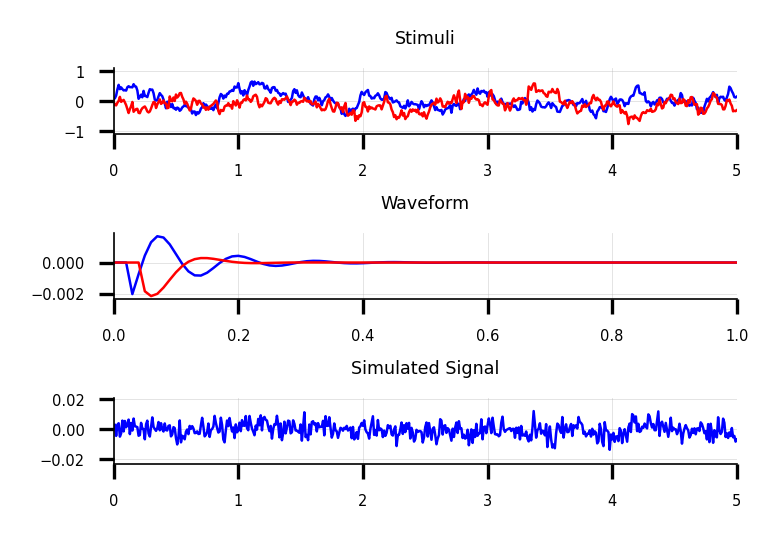

In [ ]:

fs = 100
n_feat = 2
n_channels = 1
weights_feat = [10,0.9]
T = 600
time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,
                                                              stim_type = 'continuous', n_pulse = T,
                                                              impulse_freqs = [1,10], decreasing_rates = [10,25], delays = [0.03,0.1],
                                                              weights_feat = weights_feat, weights_channel = [1],
                                                              compression_factor = 1, share_impulse = True,
                                                              snr_db = -15, beta_noise = 0.4, #0 = white, 1 = pink, 2 = red
                                                              random_seed = 0, scale_data = False)

fig, ax = plt.subplots(3,figsize = (2.5,1.7))
ax[0].plot(time_array,X)
for i in range(n_feat):
    for j in range(n_channels):
        ax[1].plot(time_array,impulse_responses[i,j])
ax[2].plot(time_array,Y)

for i in range(3):
    ax[i].set_title(['Stimuli', 'Waveform', 'Simulated Signal'][i])
ax[0].set_xlim([0,5])
ax[1].set_xlim([0,1])
ax[2].set_xlim([0,5])
fig.tight_layout()

In [ ]:
n_perm = 100
alphas = [0] + list(np.logspace(-3,3,10))
permuted_scores = np.zeros(len(non_linear_factors))

X_control = X[:,:X.shape[1]-1]
X_test = X.copy()
X_perm = np.zeros(X_test.shape)
X_perm[:,:X_control.shape[1]] = X_control
scores_perm = np.zeros(n_perm)
start = time.time()
for i in range(n_perm):
    X_perm[:,-1] = np.roll(X_test[:,-1],np.random.randint(100,X.shape[0] - 100))
    trf_perm = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas)
    scores_perm[i] = trf_perm.xval_eval(scale(X_perm), scale(Y), scoring = 'R2', verbose = False).mean(0).max(-1)[0]
print(time.time() - start)

trf_control = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas)
scores_control = trf_control.xval_eval(scale(X_control), scale(Y), scoring = 'R2', verbose = False).mean(0).max(-1)[0]

trf_test = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas)
scores_test = trf_test.xval_eval(scale(X_test), scale(Y), scoring = 'R2', verbose = False).mean(0).max(-1)[0]

173.6949541568756


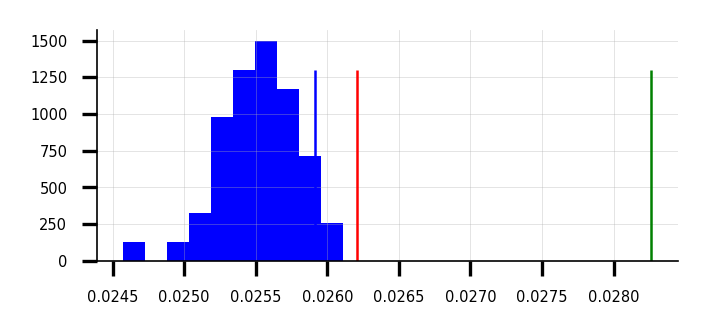

In [ ]:
fig, ax = plt.subplots(figsize = (2.5,1))
ax.hist(scores_perm, density = True)
ax.vlines(np.percentile(scores_perm,95), 0, 1300, color = 'b')
ax.vlines(scores_control, 0, 1300, color = 'r')
ax.vlines(scores_test, 0, 1300, color = 'g')

Let's also take a look at what happens if our features are very very very correlated (i.e. they're the same), how does the TRF (or most linear models for that matter) behave.

In [ ]:

fs = 100
n_feat = 1
n_channels = 1
T = 600
time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,
                                                              stim_type = 'continuous', n_pulse = T,
                                                              impulse_freqs = [1,10], decreasing_rates = [10,25], delays = [0.03,0.1],
                                                              weights_feat = [1], weights_channel = [1],
                                                              compression_factor = 1, share_impulse = True,
                                                              snr_db = -15, beta_noise = 0.4, #0 = white, 1 = pink, 2 = red
                                                              random_seed = 0, scale_data = False)

X,Y = scale(X), scale(Y)
X2 = np.hstack([X,X])

In [ ]:
tmin = 0
tmax = .5
trf1 = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas)
scores1 = trf1.xval_eval(X, Y, scoring = 'R2', verbose = False).mean(0)[0]


trf2 = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas)
scores2 = trf2.xval_eval(X2, Y, scoring = 'R2', verbose = False).mean(0)[0]

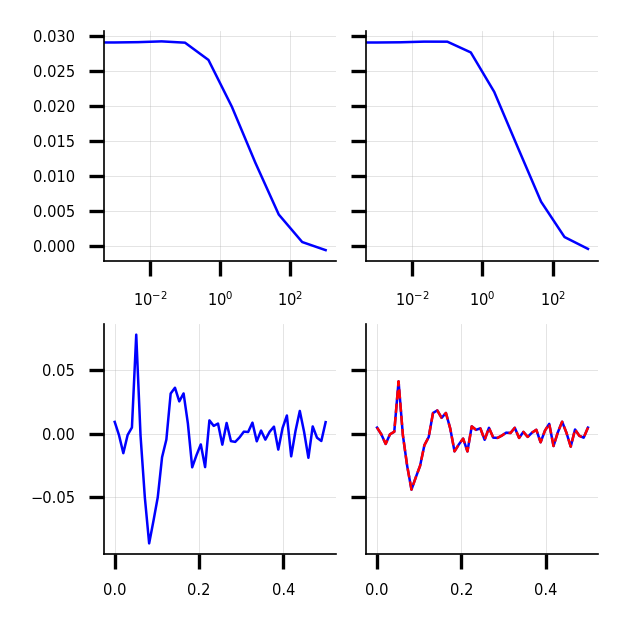

In [ ]:
fig,ax = plt.subplots(2,2,figsize = (2,2), sharey = 'row')

kernel_time = np.linspace(tmin, tmax,int((tmax-tmin)*fs))
alpha_kernel = int(np.mean([trf1.get_best_alpha(),trf2.get_best_alpha()]))


ax[0,0].plot(alphas,scores1)
ax[0,1].plot(alphas,scores2)
for i in range(2):
    ax[0,i].set_xscale('log')
ax[1,0].plot(kernel_time,scale(trf1.get_coef()[:,0,0,alpha_kernel] ** 1, with_mean = False, with_std = False))
ax[1,1].plot(kernel_time,scale(trf2.get_coef()[:,0,0,alpha_kernel] ** 1, with_mean = False, with_std = False))
ax[1,1].plot(kernel_time,scale(trf2.get_coef()[:,1,0,alpha_kernel] ** 1, with_mean = False, with_std = False), ls = '--')

fig.tight_layout()


### 3.d Targetting specific neural functions
Up until now, we've assumed the TRF made a direct link between the data and stimuli, however, as explained in previous sessions, the activity picked up by electrodes is a sum of several sources, some of which may interact. Here we will focus on one example of specific brain function (PAC) and how/why it could be encoded by the TRF. This is only one of many possiblities, as in principle, we could always try different transformations. Here we present a basic example, analog to (https://www.nature.com/articles/s41467-024-53128-1) but for the sake of simplicity, we don't fit the TRF in the complex space.
Let's first generate data where a stimulus encode the coupling strength for the phase-amplitude coupling between 1Hz and 15Hz.

In [ ]:
# Generate Data
fs = 100
n_feat = 2
n_channels = 1
alphas = np.logspace(-2,2,5)
T = 600
time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,
                                                              stim_type = 'discrete', n_pulse = 3*T,
                                                              impulse_freqs = [1,10], decreasing_rates = [10,25], delays = [0.03,0.1],
                                                              weights_feat = [], weights_channel = [1,1.5,1.9],
                                                              compression_factor = 1, share_impulse = True,
                                                              snr_db = np.inf, beta_noise = 0.4, #0 = white, 1 = pink, 2 = red
                                                              random_seed = 0, scale_data = True,
                                                               target_signal = 'PAC', PAC_lf = 1, PAC_hf= 15)

X = scale(X, with_std = True)

Weights have incoherent shape relative to number of features, set to equal weights


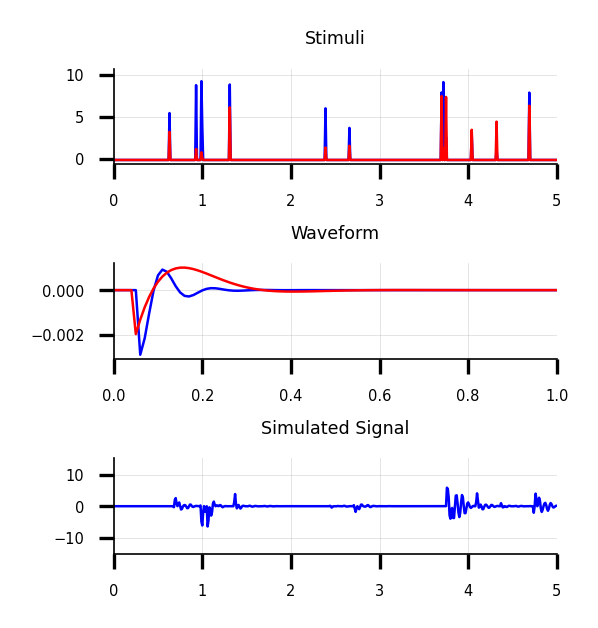

In [ ]:
fig, ax = plt.subplots(3,figsize = (1.9,2))
ax[0].plot(time_array,X)
for i in range(n_feat):
    for j in range(n_channels):
        ax[1].plot(time_array,impulse_responses[i,j])
ax[2].plot(time_array,Y)

for i in range(3):
    ax[i].set_title(['Stimuli', 'Waveform', 'Simulated Signal'][i])
ax[0].set_xlim([0,5])
ax[1].set_xlim([0,1])
ax[2].set_xlim([0,5])
fig.tight_layout()

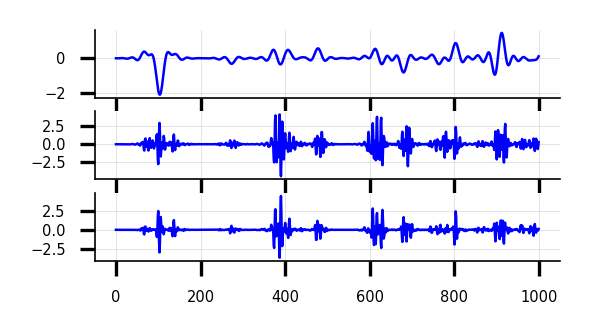

In [ ]:
s1 = mne.filter.filter_data(Y[:,0],fs,0.01,3, verbose = False)
s2 = mne.filter.filter_data(Y[:,0],fs,10,20, verbose = False)

phase = np.angle(signal.hilbert(s1))
amplitude = np.cos(phase)
pac = amplitude * s2

fig, ax = plt.subplots(3,figsize = (2,1))
ax[0].plot(s1[:1000])
ax[1].plot(s2[:1000])
ax[2].plot(pac[:1000])

<BarContainer object of 2 artists>

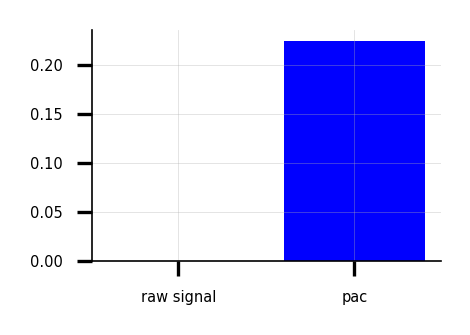

In [ ]:
tmin = 0
tmax = 0.5
trf = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = [0,1])
trf_times = trf.times
trf.xval_eval(X, Y, verbose = False)
scores_raw = trf.scores.mean(0).max(-1)

trf_pac = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas)
trf_pac.xval_eval(scale(X), scale(pac[:,np.newaxis]), verbose = False)
scores_pac = trf_pac.scores.mean(0).max(-1)

fig, ax = plt.subplots(figsize = (1.5,1))
ax.bar(x = ['raw signal','pac'],height = [scores_raw[0], scores_pac[0]])

### 3.e Handling non-linearity using Reservoir Computing (bonus)
Here, we present another model of encoding. Rather than a Ridge regression between delayed features, we use a randomly initiated recurrent neural network, from which we extract activity which are being used for the Ridge regression. This is one case of extreme machine learning(https://en.wikipedia.org/wiki/Extreme_learning_machine), which is expecially fit for the problem at hands (minimal architecture for relatively fast computation). Here we will demonstrate when it could be useful but also how, even in its simplest state, the hyperpamaters make it hard to optimize. So avoid using them unless you have a very specific question in mind. The spyeeg library mostly serves as a wrapper for reservoirpy (https://reservoirpy.readthedocs.io/en/latest/), and there are many other interesting stuff to be done with them! (https://link.springer.com/chapter/10.1007/978-3-030-61616-8_40)

In [ ]:
# Generate Data for 3 channels in response to a single feature for 10 minutes.
fs = 100
n_feat = 1
n_channels = 1
T = 600
alphas = [0] + np.logspace(-10,10,20)
compression_factor = 0.1
time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,
                                                              stim_type = 'continuous', n_pulse = T,
                                                              impulse_freqs = [1,10], decreasing_rates = [10,25], delays = [0.03,0.1],
                                                              weights_feat = [1], weights_channel = [1],
                                                              compression_factor = compression_factor, share_impulse = True,
                                                              snr_db = -5, beta_noise = 0.4, #0 = white, 1 = pink, 2 = red
                                                              random_seed = 0, scale_data = False)
X,Y = scale(X), scale(Y)

In [ ]:
units_param = [10,25,50,100]
scores_esn = np.zeros(len(units_param))

for unit_index, n_units in enumerate(units_param):
    esn = models.ESN.ESNEstimator(srate = fs, alpha = alphas, n_units = n_units,
                        reservoir_mode = 'separate', scale_reservoir = False,
                      lr = 0.4, sr = .9)
    scores_esn[unit_index] = esn.xval_eval(X,Y, verbose = False).mean(0).max(-1)
    clear_output(wait=False)

trf = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas)
trf.xval_eval(X, Y, scoring = 'R2', verbose = False)
scores_trf = trf.scores.mean(0).max(-1)

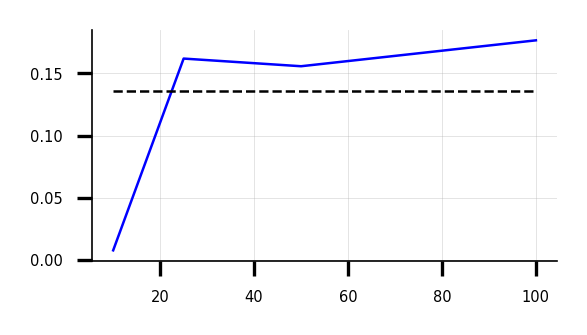

In [ ]:
fig, ax = plt.subplots(figsize = (2,1))
ax.plot(units_param,scores_esn)
ax.hlines(scores_trf,units_param[0],units_param[-1], color = 'k', ls = '--')

## 4. Backward Modelling
Unlike the Forward Modelling, Backward Modelling works in "the reverse order", in that, we decode the stimuli from the response it supposedly evoked. This matters in terms of interpretation of the coefficients but also flips how we think of features and brain signals, especially in terms of noise. Backward model generally answers a different question from forward one: "Does the brain signal contain information about the feature".

### 4.a Flipping the time : Concept of backwards model
The concept is seemingly simple, we decode the stimulus from the activity at different channels, combining them to maximally decode. In many ways, what we've said earlier stands: the R2 is negatively biased, regularization is necessary...etc, but now features are decoded individually while the number of channels increases the computing time exponentially.

In [ ]:
fs = 100
n_feat = 1
n_channels = 3
T = 600

time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,
                                                              stim_type = 'continuous', n_pulse = T,
                                                              impulse_freqs = [1,10], decreasing_rates = [10,25], delays = [0.03,0.1],
                                                              weights_feat = [], weights_channel = [1,1.5,1.9],
                                                              compression_factor = 1, share_impulse = True,
                                                              snr_db = -10, beta_noise = 0.4, #0 = white, 1 = pink, 2 = red
                                                              random_seed = 0, scale_data = False)

X,Y = scale(X), scale(Y)

In [ ]:
tmin = -0.5
tmax = 0.01
trf = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas, mtype='backward')
trf.xval_eval(Y, X, verbose = False)
trf_times = trf.times
scores = trf.scores.mean(0)[0]
best_alpha = trf.get_best_alpha()[0]
coefs = trf.get_coef()[:,:,:,best_alpha]

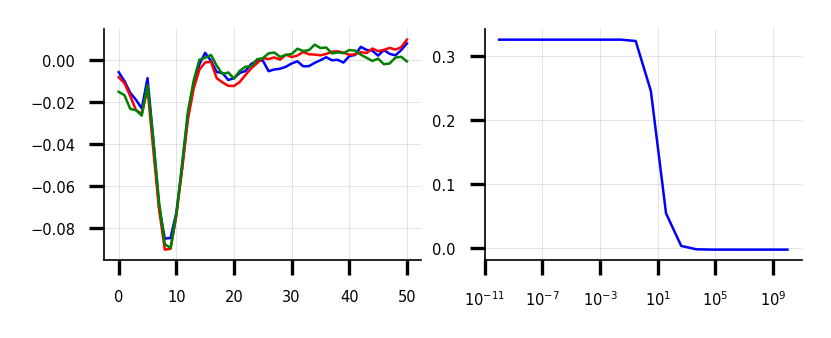

In [ ]:
fig, ax = plt.subplots(1,2, figsize = (3,1))
ax[0].plot(coefs[:,:,0])
ax[1].plot(alphas, scores)
ax[1].set_xscale('log')

### 4.b Exploiting the Redundancy or Unicity in neural data
An essential point of decoding is that we often combine channels which respond to the stimuli in a very similar manner (typically in EEG) but with a different noise content. Therefore, where the redundancy/correlation in the input space for the encoding was a problem, it serves us well, as we can 'flatten noise'. This often results in much higher R2 and a stronger statistical power than encoding, at the price of interpretability and not being able to combine the effect of different regressors (thus leading us to answer different questions).

In [ ]:
fs = 100
n_feat = 1
n_channels = 10
T = 600
share_impulse = False

time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,
                                                              stim_type = 'continuous', n_pulse = T,
                                                              impulse_freqs = [1,10], decreasing_rates = [10,25], delays = [0.03,0.1],
                                                              weights_feat = [], weights_channel = [1,1.5,1.9],
                                                              compression_factor = 1, share_impulse = share_impulse,
                                                              snr_db = -20, beta_noise = 0.4, #0 = white, 1 = pink, 2 = red
                                                              random_seed = 0, scale_data = False)

X,Y = scale(X), scale(Y)

Weights have incoherent shape relative to number of features, set to equal weights


In [ ]:
n_chan_list = np.arange(1,n_channels+1)
scores = np.zeros(len(n_chan_list))
scores_PCA = np.zeros(len(n_chan_list))
scores_ICA = np.zeros(len(n_chan_list))

tmin = -0.5
tmax = 0.01
for n_chan_index, n_chan in enumerate(n_chan_list):
    trf = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas, mtype='backward')
    trf.xval_eval(Y[:,:n_chan], X, verbose = False)
    scores[n_chan_index] = trf.scores.mean(0).max(-1)[0]

    pca = PCA(n_chan)
    Y_pca = pca.fit_transform(Y)
    trf = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas, mtype='backward')
    trf.xval_eval(Y_pca, X, verbose = False)
    scores_PCA[n_chan_index] = trf.scores.mean(0).max(-1)[0]

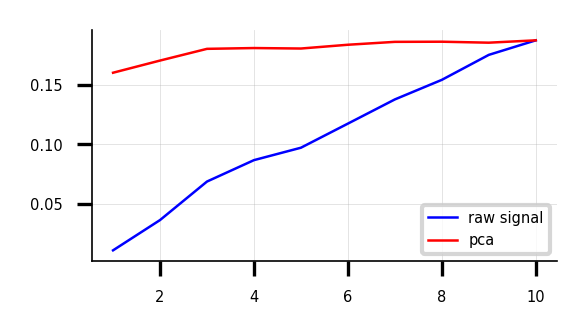

In [ ]:
fig, ax = plt.subplots(figsize = (2,1))
ax.plot(n_chan_list, scores, label = 'raw signal')
ax.plot(n_chan_list, scores_PCA, label = 'pca')
ax.legend()